In [ ]:
import rebound
import numpy as np 
import matplotlib.pyplot as plt
import pickle
from scipy.optimize import curve_fit

### Analisi angoli (magari luca l'ha fatta meglio)

In [ ]:

boxL = 10
sim = rebound.Simulation()
nx, ny = 10, 5
sim.widget(port=1271,size=(1000,1000))
sim.configure_box(boxL,nx,ny)
sim.boundary = "open"
sim.gravity = "tree"
sim.integrator = "leapfrog"
sim.softening = 0.1
sim.opening_angle2 = 1.5
np.random.seed(0)
M = 10
N = 500
m = 100
T = 50
Vx = 15
nrows = 20
ncols = int(N/nrows)
k = 0
xs = np.linspace(-nx*boxL/2,nx*boxL/2,ncols)
ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
# NON METTERE QUESTO È MOLTO STUPIDO
# for x in xs:
#     for y in ys:
#         vx = -2*Vx
#         sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/200)
sim.add(m=m,x=boxL*(nx-1)/nx,y=0,vx=0,vy=0,hash="BH",r=1)
sim.collision = "none"
steps = int(1e4)
# v = np.zeros(steps)
# theta = np.zeros(steps)
v = []
defs = []
theta = 0
i = 0
k = 0
Nparticles = sim.N
cycle = 0
particle_hash = 0
bs = []

# dt = sim.dt
def heartbeat(sim_pointer):
    global v, theta, i, Nparticles, k, cycle, defs, particle_hash,bs
    sim = sim_pointer.contents
    t = sim.t
    dt = boxL**3/(N-1)/(2*Vx)
    if np.floor(t/dt)>cycle:
        cycle += 1
        x = nx*boxL/2
        ys = np.linspace(-ny*boxL/2*0.9,ny*boxL/2*0.9,nrows)
        vx = -2*Vx
        for j, y in enumerate(ys):
            sim.add(m=M/N,x=x,y=y,vx=vx,r=boxL/100,hash=particle_hash)
            bs = np.r_[bs, j]
            particle_hash += 1
        t = 0

        Nparticles = sim.N
    
    v = np.append(v,sim.particles["BH"].vx)
    i+=1

sim.heartbeat = heartbeat

sim.integrator = "leapfrog"
# sim.integrator = "ias15"

REBOUND Webserver listening on http://localhost:1271 ...


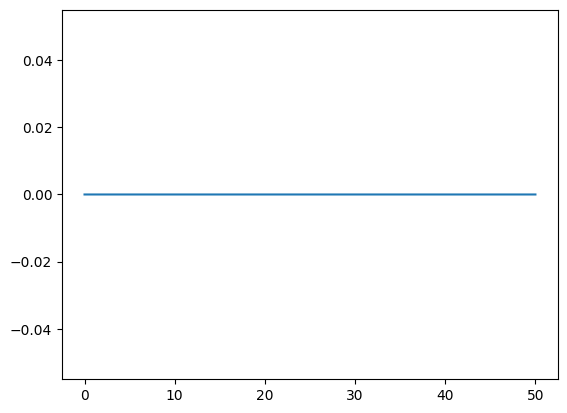

In [ ]:
fig, ax = plt.subplots()

sim.integrate(T)
# sim.steps(steps)

ts = np.linspace(0,T,len(v))
ax.plot(ts,v)
plt.show()
# fig.savefig(f"N{N}m{m}t{T}.png")

[ 0.  1.  2. ... 17. 18. 19.]


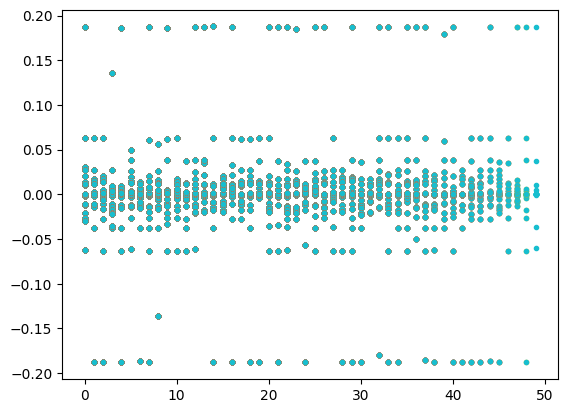

[-317.05021995 -283.76205325 -252.51112893 -213.79467447 -176.68846256
 -137.82679565  -98.71563221  -59.11715433  -19.88267      19.90530717
   59.14319658   98.71274881  137.84376919  176.70379495  213.81069112
  252.52684355  283.77761398  317.06520011  317.44094803]


/tmp/ipykernel_1731313/3533412744.py:16: RuntimeWarning: divide by zero encountered in divide
  b_over_b90 = 1/np.tan(means/2)


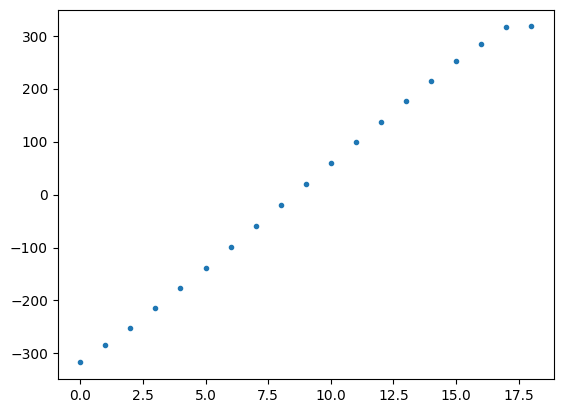

v = 15: m = 37.51573833853124


In [ ]:
means = np.zeros(nrows)
fig, ax = plt.subplots()
for b in range(1,nrows):
    defs = []
    for p in sim.particles:
        if p.hash.value != 1753590236 and bs[p.hash.value]==b:
            # if p.x<0.1*nx*boxL and (True or p.x < -0.99*nx*boxL/2 or np.abs(p.y) > 0.99*ny*boxL/2):
            deflection = np.arctan2(p.vy,p.vx)
            deflection = (np.abs(deflection)-np.pi)*np.sign(deflection)
            defs = np.r_[defs, deflection]
            ax.plot(defs,'.',label=f"{b}")
    means[b] = np.mean(defs)

print(bs)
plt.show()
b_over_b90 = 1/np.tan(means/2)
b_over_b90 = b_over_b90[1:]
Xfit = np.arange(nrows)[1:]
print(b_over_b90)
fig, ax = plt.subplots()
# ax.plot(means,'.')
ax.plot(b_over_b90,'.')
# ax.hist(np.tan(defs/2),bins=10000)
# # ax.plot(np.log(-np.tan(defs)),'.',markersize=0.1)
plt.show()

from scipy.optimize import curve_fit

popt, _ = curve_fit(lambda x, m, q: m*x + q, Xfit, b_over_b90)

print(f"v = {Vx}: m = {popt[0]}")


In [ ]:
m5 = 3.8468458761804656
m10 = 15.423398930537578
m15 = 35.403351715682646